In [1]:
import pandas as pd


In [3]:
data = pd.read_csv("/home/vo/project_price/dataset/staging/data_sau_clean.csv")

In [4]:
data.head(10)


,transaction_type,city,district,property_type,area,bedrooms,bathrooms,legal_status,posted_date,crawl_date,price,bedrooms_is_missing,bathrooms_is_missing
0,Bán,Hồ Chí Minh,Quận 9,Căn hộ chung cư,32.5,1.0,1.0,Hop_Dong,2025-06-05,2025-12-30,2.520000e+09,0,0
1,Bán,Hồ Chí Minh,Quận 9,Căn hộ chung cư,59.0,2.0,2.0,Hop_Dong,2025-06-05,2025-12-30,2.710000e+09,0,0
2,Bán,Hồ Chí Minh,Quận 12,Bán đất,300.0,1.0,1.0,So_Do_So_Hong,2025-06-05,2025-12-30,1.250000e+10,1,1
3,Bán,Hà Nội,Gia Lâm,Căn hộ chung cư,59.0,2.0,1.0,So_Do_So_Hong,2025-06-05,2025-12-30,2.700000e+09,0,0
4,Bán,Hà Nội,Nam Từ Liêm,Căn hộ chung cư,129.0,4.0,3.0,So_Do_So_Hong,2025-06-05,2025-12-30,1.135000e+10,0,0
5,Bán,Hà Nội,Tây Hồ,Nhà mặt phố,115.0,20.0,9.0,So_Do_So_Hong,2025-06-05,2025-12-30,7.700000e+10,0,0
6,Bán,Hà Nội,Cầu Giấy,Nhà riêng,62.0,4.0,5.0,So_Do_So_Hong,2025-06-05,2025-12-30,2.330000e+10,0,0
7,Bán,Hà Nội,Thanh Xuân,"Chung cư mini, căn hộ",50.0,10.0,10.0,So_Do_So_Hong,2025-06-05,2025-12-30,1.100000e+10,0,0
8,Bán,Hà Nội,Thanh Xuân,Căn hộ chung cư,64.0,2.0,2.0,So_Do_So_Hong,2025-06-05,2025-12-30,6.300000e+09,0,0
9,Bán,Hà Nội,Nam Từ Liêm,Căn hộ chung cư,92.0,3.0,2.0,So_Do_So_Hong,2025-06-05,2025-12-30,8.300000e+09,0,0


In [5]:
data.shape

(117322, 13)

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_skew_check_and_save(
    df,
    col,
    save_dir="figures",
    bins=50
):
    # Tạo thư mục nếu chưa tồn tại
    os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # -----------------------
    # Original distribution
    # -----------------------
    axes[0].hist(df[col].dropna(), bins=bins)
    axes[0].set_title(f"{col} (Original)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # -----------------------
    # Log-transformed
    # -----------------------
    axes[1].hist(np.log1p(df[col].dropna()), bins=bins)
    axes[1].set_title(f"{col} (Log-transformed)")
    axes[1].set_xlabel(f"log(1 + {col})")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()

    # Tên file theo chuẩn paper
    file_path = os.path.join(save_dir, f"{col}_log_transform.png")

    # Lưu hình (dpi cao cho bài báo)
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"Saved figure to: {file_path}")



In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_skew_check_and_save(
    df,
    col,
    save_dir="figures",
    bins=50
):
    os.makedirs(save_dir, exist_ok=True)

    data = df[col].dropna().values
    log_data = np.log1p(data)

    # -----------------------
    # Springer-style config
    # -----------------------
    plt.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10
    })

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # -----------------------
    # Original distribution (clipped)
    # -----------------------
    upper = np.percentile(data, 99)

    axes[0].hist(
        data,
        bins=bins,
        color="lightgray",
        edgecolor="black",
        linewidth=0.8
    )
    axes[0].set_xlim(0, upper)
    axes[0].set_title("Original Price Distribution (99% clipped)")
    axes[0].set_xlabel("Price")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    # -----------------------
    # Log-transformed distribution
    # -----------------------
    axes[1].hist(
        log_data,
        bins=bins,
        color="lightgray",
        edgecolor="black",
        linewidth=0.8
    )
    axes[1].set_title("Log-transformed Price Distribution")
    axes[1].set_xlabel("log(1 + Price)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()

    file_path = os.path.join(save_dir, f"{col}_log_transform_springer.png")
    plt.savefig(file_path, bbox_inches="tight")
    plt.close()

    print(f"[Springer] Saved figure to: {file_path}")


In [7]:
plot_skew_check_and_save(data, "area")
plot_skew_check_and_save(data, "price")


[Springer] Saved figure to: figures/price_log_transform_springer.png


In [113]:
data.columns


Index(['transaction_type', 'city', 'district', 'property_type', 'area',
       'bedrooms', 'bathrooms', 'legal_status', 'posted_date', 'crawl_date',
       'price', 'bedrooms_is_missing', 'bathrooms_is_missing'],
      dtype='object')

In [6]:
data.dtypes

Loại giao dịch           object
Thành phố                object
Quận/huyện               object
Loại hình đất            object
Mức giá                  object
Diện tích                object
Số phòng ngủ             object
Số phòng tắm, vệ sinh    object
Số tầng                  object
Hướng nhà                object
Hướng ban công           object
Mặt tiền                 object
Đường vào                object
Pháp lý                  object
Nội thất                 object
Ngày đăng                object
crawl_date               object
dtype: object

In [116]:
MIN_CITY_COUNT = 100

city_counts = data['city'].value_counts()






In [117]:
rare_cities = city_counts[city_counts < MIN_CITY_COUNT].index

In [118]:
data['city'] = data['city'].where(
    ~data['city'].isin(rare_cities),
    'Other'
)

print("Unique cities after grouping:", data['city'].nunique())

Unique cities after grouping: 13


In [119]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['city', 'district', 'property_type', 'transaction_type', 'legal_status']
cat_cols = [col for col in cat_cols if col in data.columns]

# Fill missing
data[cat_cols] = data[cat_cols].fillna('Unknown').astype(str)

ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoded = ohe.fit_transform(data[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=data.index
)

# Ghép lại dataframe
data  = pd.concat([data.drop(columns=cat_cols), encoded_df], axis=1)


In [120]:
num_cols = [
    'area',
    'bedrooms',
    'bathrooms'
]


In [121]:
q_low, q_high = data['price'].quantile([0.01, 0.99])
data = data[(data['price'] >= q_low) & (data['price'] <= q_high)]


In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data[num_cols] = scaler.fit_transform(data[num_cols])


In [123]:
data['posted_ts'] = pd.to_datetime(data['posted_date']).astype('int64') // 10**9
data['crawl_ts']  = pd.to_datetime(data['crawl_date']).astype('int64') // 10**9

date_cols = ['posted_ts', 'crawl_ts']
data[date_cols] = scaler.fit_transform(data[date_cols])

data  = data.drop(columns=['posted_date', 'crawl_date'])



In [124]:
import numpy as np

In [125]:


data['price'] = np.log1p(data['price'])


In [126]:
data.head(5)

,area,bedrooms,bathrooms,price,bedrooms_is_missing,bathrooms_is_missing,city_Bà Rịa Vũng Tàu,city_Bình Dương,city_Hà Nội,city_Hưng Yên,...,transaction_type_Bán,transaction_type_Cho thuê,legal_status_Dang_Cho_So,legal_status_Hop_Dong,legal_status_Other_Unknown,legal_status_So_Do_So_Hong,legal_status_Unknown,legal_status_Vi_Bang,posted_ts,crawl_ts
0,-0.773573,-0.692638,-0.643760,21.647525,0,0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.600543,-0.505558
1,-0.543491,-0.438369,-0.367543,21.720214,0,0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.600543,-0.505558
2,1.548948,-0.438369,-0.643760,23.248994,1,1,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.600543,-0.505558
3,-0.543491,-0.438369,-0.643760,21.716518,0,0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.600543,-0.505558
4,0.064271,0.070168,-0.091326,23.152484,0,0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.600543,-0.505558


In [127]:
data.shape

(14743, 338)

In [128]:
data.columns

Index(['area', 'bedrooms', 'bathrooms', 'price', 'bedrooms_is_missing',
       'bathrooms_is_missing', 'city_Bà Rịa Vũng Tàu', 'city_Bình Dương',
       'city_Hà Nội', 'city_Hưng Yên',
       ...
       'transaction_type_Bán', 'transaction_type_Cho thuê',
       'legal_status_Dang_Cho_So', 'legal_status_Hop_Dong',
       'legal_status_Other_Unknown', 'legal_status_So_Do_So_Hong',
       'legal_status_Unknown', 'legal_status_Vi_Bang', 'posted_ts',
       'crawl_ts'],
      dtype='object', length=338)

In [129]:
X = data.drop(columns=['price'])
y = data['price'].values


In [130]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


In [131]:
import numpy as np

def train_model(model, X_train, y_train_log):
    """
    Train model với y đã log-transform

    Parameters
    ----------
    model : object
        Model có hàm fit(X, y)
    X_train : pd.DataFrame | np.ndarray
    y_train_log : np.ndarray
        y = log1p(price)
    """
    model.fit(X_train, y_train_log)
    return model


In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test_log):
    """
    Evaluate model trên scale gốc (price thật)

    Returns
    -------
    metrics : dict
    """
    # predict log
    y_pred_log = model.predict(X_test)

    # inverse log
    y_test = np.expm1(y_test_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }


In [133]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

model = train_model(model, X_train, y_train)

metrics = evaluate_model(model, X_test, y_test)
print(metrics)


{'MAE': 4395380451.948863, 'RMSE': np.float64(10009336094.305199), 'R2': 0.6695656111133774, 'MAPE': np.float64(61.85399278830391)}


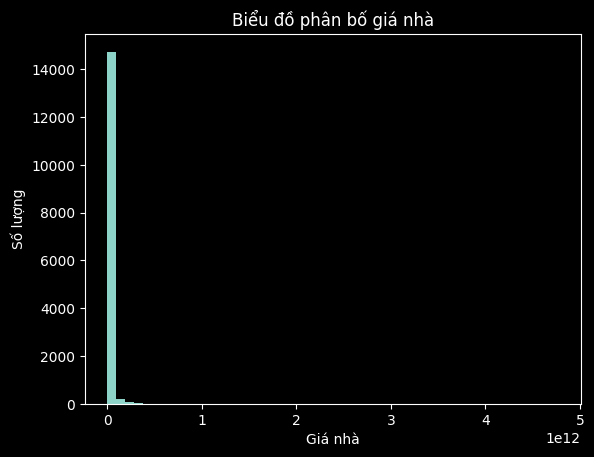

In [5]:
import matplotlib.pyplot as plt

# Giả sử DataFrame tên df, cột giá là "price"
prices = data["price"]

plt.figure()
plt.hist(prices, bins=50)
plt.xlabel("Giá nhà")
plt.ylabel("Số lượng")
plt.title("Biểu đồ phân bố giá nhà")
plt.show()


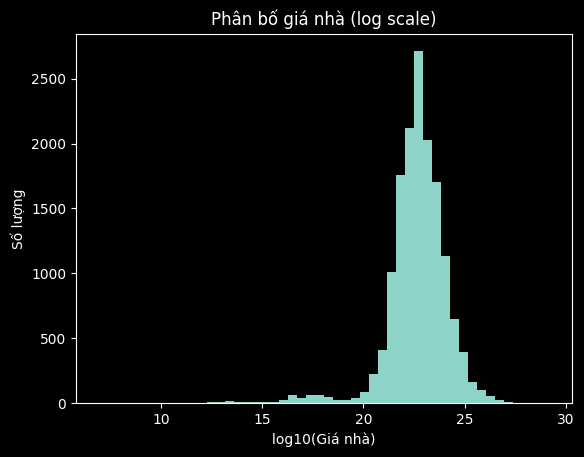

In [6]:
import numpy as np
import matplotlib.pyplot as plt

price = data["price"]
price = price[price > 0]

plt.figure()
plt.hist(np.log1p(price), bins=50)
plt.xlabel("log10(Giá nhà)")
plt.ylabel("Số lượng")
plt.title("Phân bố giá nhà (log scale)")
plt.show()


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



PRICE_MIN = 1_000_000_000      # 1 tỷ
Q_LOW = 0.005                 # 0.5%
Q_HIGH = 0.995                # 99.5%

NUM_COLS = ['area', 'bedrooms', 'bathrooms', 'posted_ts', 'crawl_ts']


df = data.copy()


# =============================
# 2. LỌC GIÁ THẤP
# =============================
df = df[df['price'] >= PRICE_MIN]


# =============================
# 3. CẮT OUTLIER (PRICE GỐC)
# =============================
low = df['price'].quantile(Q_LOW)
high = df['price'].quantile(Q_HIGH)

df = df[(df['price'] >= low) & (df['price'] <= high)]

print(f"Rows after filter: {len(df)}")
print(f"Price range: {df['price'].min():,.0f} → {df['price'].max():,.0f}")


# =============================
# 4. SPLIT X / y
# =============================
X = df.drop(columns=['price'])
y = np.log1p(df['price'].values)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =============================
# 5. SCALE NUMERIC (FIT TRAIN ONLY)
# =============================
scaler = StandardScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])


# =============================
# 6. TRAIN MODEL
# =============================
model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=400,
    random_state=42
)

model.fit(X_train, y_train)


# =============================
# 7. PREDICT + INVERSE LOG
# =============================
y_pred_log = model.predict(X_test)

y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)


# =============================
# 8. METRICS
# =============================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


print("\n=== METRICS ===")
print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =============================
# CONFIG
# =============================
NUM_COLS = ['area', 'bedrooms', 'bathrooms', 'posted_ts', 'crawl_ts']


# =============================
# 1. COPY DATA (đã filter city, outlier, price_min)
# =============================
df = data_filtered.copy()   # hoặc data sau các bước bạn đã làm


# =============================
# 2. SPLIT X / y
# =============================
X = df.drop(columns=['price'])
y = np.log1p(df['price'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =============================
# 3. SCALE NUMERIC
# (GB không bắt buộc scale, nhưng để công bằng với MLP)
# =============================
scaler = StandardScaler()

X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test[NUM_COLS]  = scaler.transform(X_test[NUM_COLS])


# =============================
# 4. TRAIN BASELINE MODEL
# =============================
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)


# =============================
# 5. PREDICT + INVERSE LOG
# =============================
y_pred_log = gbr.predict(X_test)

y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)


# =============================
# 6. METRICS
# =============================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


print("\n=== GRADIENT BOOSTING BASELINE ===")
print(f"MAE  : {mae:,.0f}")
print(f"RMSE : {rmse:,.0f}")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")
